In [1]:
import os
import shutil
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [2]:
source_dir = "flower_photos/flower_photos/"
base_dir = "data"

splits = {"train": 0.7, "val": 0.15, "test": 0.15}


for split in splits:
    for cls in os.listdir(source_dir):
        if not os.path.isdir(os.path.join(source_dir, cls)):
            continue
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

for cls in os.listdir(source_dir):
    class_path = os.path.join(source_dir, cls)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    for i, img in enumerate(images):
        if i < train_end:
            split = "train"
        elif i < val_end:
            split = "val"
        else:
            split = "test"

        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(base_dir, split, cls, img)
        )

print("Dataset split complete")

Dataset split complete


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder("data/train", transform=train_transforms)
val_dataset = datasets.ImageFolder("data/val", transform=val_test_transforms)
test_dataset = datasets.ImageFolder("data/test", transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [4]:
model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(train_dataset.classes))
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

c:\Users\User\Documents\Second Semester (2026 FINAL SEMESTER)\Computer Vision\Project\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\Documents\Second Semester (2026 FINAL SEMESTER)\Computer Vision\Project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

epochs = 30
for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            v_loss = criterion(outputs, labels)
            running_val_loss += v_loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    acc = correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.2f}, Val Loss={avg_val_loss:.2f}, Val Acc={acc:.4f}")

  3%|▎         | 1/30 [00:42<20:28, 42.38s/it]

Epoch 1: Train Loss=0.82, Val Loss=0.37, Val Acc=0.8695


  7%|▋         | 2/30 [01:22<19:05, 40.92s/it]

Epoch 2: Train Loss=0.50, Val Loss=0.34, Val Acc=0.8767


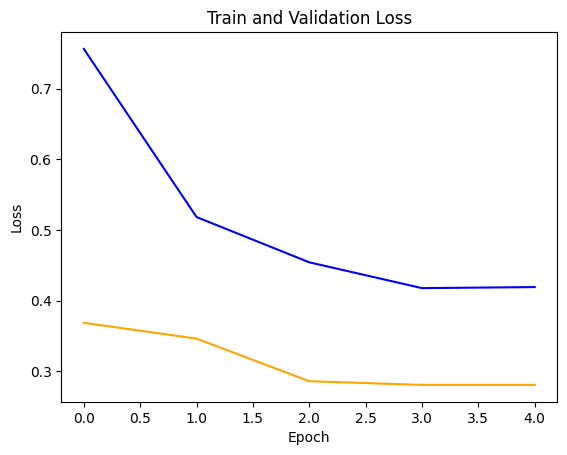

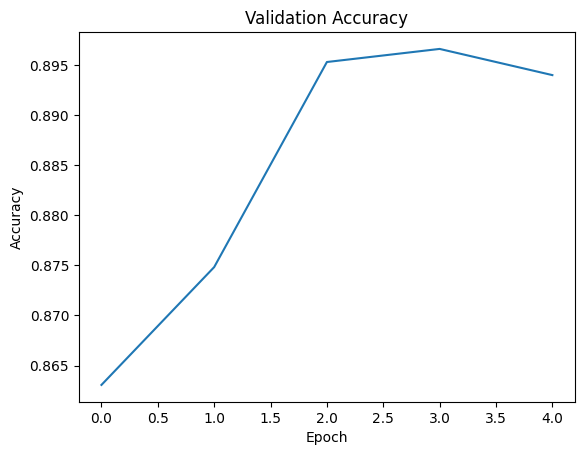

Confusion Matrix:
 [[351  13  15   6   9]
 [ 12 480  13  33   7]
 [  2   0 380   3  22]
 [  1   4   8 417   7]
 [  3   4  64   6 417]]

Classification Report:
               precision    recall  f1-score   support

       daisy       0.95      0.89      0.92       394
   dandelion       0.96      0.88      0.92       545
       roses       0.79      0.93      0.86       407
  sunflowers       0.90      0.95      0.92       437
      tulips       0.90      0.84      0.87       494

    accuracy                           0.90      2277
   macro avg       0.90      0.90      0.90      2277
weighted avg       0.90      0.90      0.90      2277



In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)

plt.plot(train_losses, label="Training loss", color="blue")
plt.plot(val_losses, label="Validation loss", color="orange")
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

print("\nClassification Report:\n",
      classification_report(all_labels, all_preds, target_names=train_dataset.classes))

In [ ]:
class HookExtractor:
    def __init__(self, module):
        self.features = None
        self.gradients = None
        
        self.forward_handle = module.register_forward_hook(self._forward_hook)
        self.backward_handle = module.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.features = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [ ]:
images_per_class = 30
base_output_dir = "gradcam_by_class"

os.makedirs(base_output_dir, exist_ok=True)

saved_counts = {}
for class_name in train_dataset.classes:
    os.makedirs(os.path.join(base_output_dir, class_name), exist_ok=True)
    saved_counts[class_name] = 0

target_layer = model.layer4[-1]
extractor = HookExtractor(target_layer)
model.eval()

for i in range(len(test_dataset)):
    if all(count >= images_per_class for count in saved_counts.values()):
        break

    img, label = test_dataset[i]
    true_class_name = train_dataset.classes[label]

    if saved_counts[true_class_name] >= images_per_class:
        continue

    input_tensor = img.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    outputs = model(input_tensor)
    _, preds = torch.max(outputs, 1)
    predicted_class = preds.item()
    pred_class_name = train_dataset.classes[predicted_class]

    model.zero_grad()
    class_loss = outputs[0, predicted_class]
    class_loss.backward()

    features = extractor.features
    gradients = extractor.gradients

    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * features, dim=1)
    cam = torch.relu(cam)

    cam_resized = F.interpolate(
        cam.unsqueeze(1),
        size=(img.shape[1], img.shape[2]),
        mode='bilinear',
        align_corners=False
    ).squeeze()

    cam_normalized = cam_resized - cam_resized.min()
    cam_normalized = cam_normalized / (cam_normalized.max() + 1e-8)
    grayscale_cam = cam_normalized.cpu().detach().numpy()

    img_np = img.permute(1, 2, 0).cpu().detach().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    plt.imshow(grayscale_cam, cmap='jet', alpha=0.5)
    plt.title(f"True: {true_class_name} | Pred: {pred_class_name}")
    plt.axis('off')

    current_count = saved_counts[true_class_name]
    filename = f"cam_{true_class_name}_{current_count}_pred_{pred_class_name}.png"
    filepath = os.path.join(base_output_dir, true_class_name, filename)

    plt.savefig(filepath, bbox_inches='tight')
    plt.close()

    saved_counts[true_class_name] += 1

extractor.remove()